# Membro 3 — DenseNet (121 → 169)
## Aplicação de Sistemas Inteligentes — Comparativo de Arquiteturas CNN

| Variação | Peso | Backbone | Épocas | Resolução | LR |
|---|---|---|---|---|---|
| V1 | Muito Leve | DenseNet-121 100% congelado | 12 | 224 | 1e-3 |
| V2 | Muito Leve | DenseNet-169 100% congelado | 12 | 224 | 1e-3 |
| V3 | Leve | DenseNet-121 DenseBlock4 livre | 22 | 224 | 1e-4 |
| V4 | Leve | DenseNet-121 DenseBlock4 + Scheduler | 25 | 224 | 1e-4 |
| V5 | Médio | DenseNet-121 DenseBlocks 3+4 livres | 35 | 224 | 5e-5 |
| V6 | Médio | DenseNet-169 DenseBlocks 3+4 + 256px | 40 | 256 | 5e-5 |
| V7 | Pesado | DenseNet-121 FT completo + TTA | 50 | 256 | 1e-5 |
| V8 | Pesado | DenseNet-169 FT completo + TTA | 60 | 299 | 1e-5 |

> **Registrar para cada variação:** Accuracy · F1 Macro · Precision · Recall · Loss · Tempo (min) · curvas treino/val · matriz de confusão


## 1 · Instalação de dependências

In [1]:
import importlib

required = [
    "torch",
    "torchvision",
    "timm",
    "sklearn",
    "matplotlib",
]

missing = []

for pkg in required:
    if importlib.util.find_spec(pkg) is None:
        missing.append(pkg)

if missing:
    print("Pacotes faltando:", missing)
else:
    print("✅ Todas as dependências instaladas")


✅ Todas as dependências instaladas


## 2 · Imports e configuração global

In [2]:
import os, time, itertools, joblib
from pathlib import Path
from copy import deepcopy

import numpy as np
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import timm
from sklearn.metrics import (classification_report, confusion_matrix,
                              f1_score, precision_score, recall_score)
from sklearn.model_selection import StratifiedShuffleSplit
from torch.utils.data import DataLoader, Subset
from torchvision import datasets, transforms
from torchvision.models import (
    densenet121, DenseNet121_Weights,
    densenet169, DenseNet169_Weights,
)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device: {device}")
if device.type == "cuda":
    print(f"GPU: {torch.cuda.get_device_name(0)}")


Device: cuda
GPU: NVIDIA GeForce RTX 3060 Laptop GPU


## 3 · Configuração do dataset
> ⚠️ **Ajuste `DATA_ROOT` para apontar para a sua pasta de imagens.**
> A pasta deve ter subpastas por classe (padrão `ImageFolder`).

In [3]:
# ─── CONFIGURE AQUI ───────────────────────────────────────────────────────
DATA_ROOT = Path("..\\data_sets\\ovarian_ultrasound_dataset")
# ──────────────────────────────────────────────────────────────────────────

if not DATA_ROOT.exists():
    raise FileNotFoundError(
        f"\n❌ Pasta não encontrada: {DATA_ROOT.resolve()}"
        f"\n   Ajuste DATA_ROOT na célula acima."
    )

# Detecta se já há split train/validation pré-definido
use_predefined_split = (
    (DATA_ROOT / "train").exists() and
    (DATA_ROOT / "validation").exists()
)

IMAGENET_MEAN = [0.485, 0.456, 0.406]
IMAGENET_STD  = [0.229, 0.224, 0.225]

# Verificação rápida de classes
_probe = datasets.ImageFolder(DATA_ROOT / "train" if use_predefined_split else DATA_ROOT)
CLASS_NAMES = _probe.classes
NUM_CLASSES = len(CLASS_NAMES)

print(f"Dataset  : {DATA_ROOT.resolve()}")
print(f"Classes  : {CLASS_NAMES}  ({NUM_CLASSES} classes)")
print(f"Split    : {'pré-definido (train/validation)' if use_predefined_split else 'gerado automaticamente 80/20 estratificado'}")


Dataset  : C:\Users\brian\Desktop\Uni\sistemas_int\ovary\data_sets\ovarian_ultrasound_dataset
Classes  : ['Dominant_Follicle', 'Normal', 'PCO']  (3 classes)
Split    : gerado automaticamente 80/20 estratificado


## 4 · Pipeline de dados (modular)
As transformações são definidas por nível de augmentation para reaproveitamento em todas as variações.

In [4]:
def get_transforms(aug_level: str, img_size: int = 224):
    """
    aug_level:
        'minimal'  → flip H
        'minimal_rot' → flip H + rotação ±10°  (V2 EfficientNet)
        'light'    → flip H/V + rot ±15°
        'light_jitter' → flip + jitter cor leve
        'moderate' → flip + rot + jitter cor + blur
        'moderate_crop' → flip + rot + jitter + RandomCrop
        'heavy'    → flip + rot + jitter + RandomErasing
    """
    normalize = transforms.Normalize(IMAGENET_MEAN, IMAGENET_STD)

    aug_map = {
        "minimal": [
            transforms.RandomHorizontalFlip(),
        ],
        "minimal_rot": [
            transforms.RandomHorizontalFlip(),
            transforms.RandomRotation(10),
        ],
        "light": [
            transforms.RandomHorizontalFlip(),
            transforms.RandomVerticalFlip(),
            transforms.RandomRotation(15),
        ],
        "light_jitter": [
            transforms.RandomHorizontalFlip(),
            transforms.RandomVerticalFlip(),
            transforms.RandomRotation(15),
            transforms.ColorJitter(brightness=0.15, contrast=0.15),
        ],
        "moderate": [
            transforms.RandomHorizontalFlip(),
            transforms.RandomVerticalFlip(),
            transforms.RandomRotation(15),
            transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.1),
            transforms.GaussianBlur(kernel_size=3, sigma=(0.1, 1.0)),
        ],
        "moderate_crop": [
            transforms.RandomHorizontalFlip(),
            transforms.RandomVerticalFlip(),
            transforms.RandomRotation(15),
            transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.1),
            transforms.RandomResizedCrop(img_size, scale=(0.8, 1.0)),
        ],
        "heavy": [
            transforms.RandomHorizontalFlip(),
            transforms.RandomVerticalFlip(),
            transforms.RandomRotation(20),
            transforms.ColorJitter(brightness=0.3, contrast=0.3, saturation=0.2),
        ],
    }

    pre_tensor = [transforms.Resize((img_size, img_size))] + aug_map[aug_level]
    post_tensor = [transforms.ToTensor(), normalize]

    if aug_level == "heavy":
        post_tensor.append(transforms.RandomErasing(p=0.3, scale=(0.02, 0.2)))

    train_tfms = transforms.Compose(pre_tensor + post_tensor)
    val_tfms   = transforms.Compose([
        transforms.Resize((img_size, img_size)),
        transforms.ToTensor(),
        normalize,
    ])
    return train_tfms, val_tfms


def make_loaders(train_tfms, val_tfms, batch_size=32):
    """Cria DataLoaders respeitando split pré-definido ou estratificado."""
    if use_predefined_split:
        train_ds = datasets.ImageFolder(DATA_ROOT / "train",      transform=train_tfms)
        val_ds   = datasets.ImageFolder(DATA_ROOT / "validation", transform=val_tfms)
    else:
        full_ds = datasets.ImageFolder(DATA_ROOT)
        targets = [y for _, y in full_ds.samples]
        sss = StratifiedShuffleSplit(n_splits=1, test_size=0.2, random_state=42)
        train_idx, val_idx = next(sss.split(np.zeros(len(targets)), targets))

        train_ds_src = datasets.ImageFolder(DATA_ROOT, transform=train_tfms)
        val_ds_src   = datasets.ImageFolder(DATA_ROOT, transform=val_tfms)
        train_ds     = Subset(train_ds_src, train_idx)
        val_ds       = Subset(val_ds_src,   val_idx)

    nw = min(4, os.cpu_count() or 1) if device.type == "cuda" else 0
    train_loader = DataLoader(train_ds, batch_size=batch_size, shuffle=True,  num_workers=nw, pin_memory=True)
    val_loader   = DataLoader(val_ds,   batch_size=batch_size, shuffle=False, num_workers=nw, pin_memory=True)
    return train_loader, val_loader

print("✅ Pipeline de dados pronto")


✅ Pipeline de dados pronto


## 5 · Utilitários de treinamento

In [5]:
# ─── Loop de época ────────────────────────────────────────────────────────
def run_epoch(model, loader, optimizer=None, criterion=None, train=True, scheduler=None):
    model.train(mode=train)
    total_loss, total_correct, total = 0.0, 0, 0
    all_preds, all_targets = [], []

    with torch.set_grad_enabled(train):
        for X, y in loader:
            X, y = X.to(device), y.to(device)
            if train:
                optimizer.zero_grad()
            logits = model(X)
            loss = criterion(logits, y)
            if train:
                loss.backward()
                optimizer.step()
            preds = logits.argmax(1)
            total_loss     += loss.item() * y.size(0)
            total_correct  += (preds == y).sum().item()
            total          += y.size(0)
            all_preds.append(preds.detach().cpu().numpy())
            all_targets.append(y.detach().cpu().numpy())

    avg_loss = total_loss / total
    acc      = total_correct / total
    y_true   = np.concatenate(all_targets)
    y_pred   = np.concatenate(all_preds)
    f1       = f1_score(y_true, y_pred, average="macro", zero_division=0)
    return avg_loss, acc, f1, y_true, y_pred


# ─── TTA (Test-Time Augmentation) ─────────────────────────────────────────
def tta_predict(model, loader, img_size=256, n_aug=4):
    """Flip H + crop central + rotação ±5° — média das probabilidades."""
    model.eval()
    all_probs, all_targets = [], []
    with torch.no_grad():
        for X, y in loader:
            X, y = X.to(device), y.to(device)
            probs = torch.softmax(model(X), dim=1)
            # flip horizontal
            probs_flip = torch.softmax(model(torch.flip(X, dims=[3])), dim=1)
            probs_avg = (probs + probs_flip) / 2
            all_probs.append(probs_avg.cpu())
            all_targets.append(y.cpu())
    probs_stack = torch.cat(all_probs, dim=0)
    targets_all  = torch.cat(all_targets, dim=0).numpy()
    preds = probs_stack.argmax(1).numpy()
    f1 = f1_score(targets_all, preds, average="macro", zero_division=0)
    acc = (preds == targets_all).mean()
    return acc, f1, targets_all, preds


# ─── Treinamento completo ──────────────────────────────────────────────────
def train_model(model, train_loader, val_loader, epochs, lr,
                scheduler_fn=None, label_smoothing=0.0, weight_decay=0.0,
                var_name="V?", use_tta=False, img_size=224, patience=25):
    """
    Treina e valida o modelo, registra histórico e retorna resultados.
    scheduler_fn: callable(optimizer) → scheduler  |  None
    Usa early stopping baseado em val_loss (patience).
    """
    criterion = nn.CrossEntropyLoss(label_smoothing=label_smoothing)
    optimizer = torch.optim.AdamW(
        filter(lambda p: p.requires_grad, model.parameters()),
        lr=lr, weight_decay=weight_decay
    )
    scheduler = scheduler_fn(optimizer) if scheduler_fn else None

    history = {k: [] for k in ["train_loss","val_loss","train_acc","val_acc","val_f1"]}
    best_state = None
    best_loss  = float('inf')
    best_f1    = 0.0
    best_yt, best_yp = None, None
    t0 = time.time()
    epochs_no_improve = 0

    for e in range(1, epochs + 1):
        tr_loss, tr_acc, _, _, _         = run_epoch(model, train_loader, optimizer, criterion, train=True)
        va_loss, va_acc, va_f1, yt, yp   = run_epoch(model, val_loader,   optimizer, criterion, train=False)

        if scheduler:
            if isinstance(scheduler, torch.optim.lr_scheduler.ReduceLROnPlateau):
                scheduler.step(va_loss)
            else:
                scheduler.step()

        for k, v in zip(history.keys(), [tr_loss, va_loss, tr_acc, va_acc, va_f1]):
            history[k].append(v)

        if va_loss < best_loss:
            best_loss  = va_loss
            best_f1    = va_f1
            best_state = deepcopy(model.state_dict())
            best_yt, best_yp = yt, yp
            epochs_no_improve = 0
        else:
            epochs_no_improve += 1
            if epochs_no_improve >= patience:
                print(f"  Early stop na época {e}")
                break

        print(f"  [{e:>3}/{epochs}] loss {tr_loss:.4f}/{va_loss:.4f}  "
              f"acc {tr_acc:.4f}/{va_acc:.4f}  f1_val {va_f1:.4f}")

    elapsed = (time.time() - t0) / 60
    model.load_state_dict(best_state)

    if use_tta:
        print("  → Aplicando TTA...")
        tta_acc, tta_f1, best_yt, best_yp = tta_predict(model, val_loader, img_size)
        print(f"  TTA  acc={tta_acc:.4f}  f1={tta_f1:.4f}")
        final_acc, final_f1 = tta_acc, tta_f1
    else:
        final_acc = history["val_acc"][-1]
        final_f1  = best_f1

    precision = precision_score(best_yt, best_yp, average="macro", zero_division=0)
    recall    = recall_score   (best_yt, best_yp, average="macro", zero_division=0)

    results = {
        "variacao": var_name,
        "accuracy": round(final_acc, 4),
        "f1_macro": round(final_f1,  4),
        "precision": round(precision, 4),
        "recall":   round(recall,    4),
        "loss":     round(best_loss, 4),
        "tempo_min": round(elapsed, 1),
    }
    return model, history, results, best_yt, best_yp


# ─── Plots ────────────────────────────────────────────────────────────────
def plot_curves(history, var_name):
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))
    ax1.plot(history["train_loss"], label="train"); ax1.plot(history["val_loss"], label="val")
    ax1.set_title(f"{var_name} — Loss"); ax1.set_xlabel("epoch"); ax1.legend()
    ax2.plot(history["train_acc"],  label="train"); ax2.plot(history["val_acc"],  label="val")
    ax2.set_title(f"{var_name} — Accuracy"); ax2.set_xlabel("epoch"); ax2.legend()
    plt.tight_layout(); plt.show()

def plot_cm(y_true, y_pred, class_names, var_name, normalize=True):
    cm = confusion_matrix(y_true, y_pred)
    if normalize:
        cm = cm.astype(float) / cm.sum(axis=1, keepdims=True)
    plt.figure(figsize=(max(5, len(class_names)*1.2), max(4, len(class_names))))
    plt.imshow(cm, cmap="Blues")
    plt.title(f"{var_name} — Matriz de Confusão {'Normalizada' if normalize else ''}")
    plt.colorbar()
    ticks = np.arange(len(class_names))
    plt.xticks(ticks, class_names, rotation=45, ha="right")
    plt.yticks(ticks, class_names)
    fmt = ".2f" if normalize else "d"
    thresh = cm.max() / 2
    for i, j in itertools.product(range(cm.shape[0]), range(cm.shape[1])):
        plt.text(j, i, format(cm[i,j], fmt), ha="center",
                 color="white" if cm[i,j] > thresh else "black", fontsize=9)
    plt.ylabel("Real"); plt.xlabel("Previsto")
    plt.tight_layout(); plt.show()

def show_results(res):
    print(f"\n{'─'*55}")
    print(f"  {res['variacao']} — Resultados Finais")
    print(f"{'─'*55}")
    print(f"  Accuracy   : {res['accuracy']:.4f}")
    print(f"  F1 Macro   : {res['f1_macro']:.4f}")
    print(f"  Precision  : {res['precision']:.4f}")
    print(f"  Recall     : {res['recall']:.4f}")
    print(f"  Loss (val) : {res['loss']:.4f}")
    print(f"  Tempo      : {res['tempo_min']} min")
    print(f"{'─'*55}")

print("✅ Utilitários de treinamento prontos")


✅ Utilitários de treinamento prontos


## 6 · Tabela de resultados
Acumula todas as variações automaticamente.

In [6]:
ALL_RESULTS = []   # preenchido automaticamente após cada variação

def print_results_table():
    if not ALL_RESULTS:
        print("Nenhum resultado ainda.")
        return
    header = f"{'Var':<6} {'Backbone':<30} {'Acc':>6} {'F1':>6} {'Prec':>6} {'Rec':>6} {'Loss':>6} {'Tempo':>6}"
    print(header)
    print("─" * len(header))
    for r in ALL_RESULTS:
        print(f"{r['variacao']:<6} {r.get('backbone','—'):<30} "
              f"{r['accuracy']:>6.4f} {r['f1_macro']:>6.4f} "
              f"{r['precision']:>6.4f} {r['recall']:>6.4f} "
              f"{r['loss']:>6.4f} {r['tempo_min']:>5.1f}m")

print("✅ Tabela pronta — execute print_results_table() a qualquer momento")


✅ Tabela pronta — execute print_results_table() a qualquer momento


In [7]:
# ─── Salvamento de modelos ────────────────────────────────────────────────
SAVE_DIR = Path("modelos_salvos") / "membro3"
SAVE_DIR.mkdir(parents=True, exist_ok=True)

def save_model(model, var_name: str) -> Path:
    """
    Salva o modelo completo em .joblib dentro de SAVE_DIR.
    Nome do arquivo: membro3_<var_name_sanitizado>.joblib
    """
    safe = var_name.replace(" ", "_").replace("/", "-")
    path = SAVE_DIR / f"membro3_{safe}.joblib"
    joblib.dump(model, path)
    print(f"  💾 Modelo salvo → {path}")
    return path

print(f"✅ Função save_model pronta  |  pasta: {SAVE_DIR.resolve()}")


✅ Função save_model pronta  |  pasta: C:\Users\brian\Desktop\Uni\sistemas_int\ovary\image_augmentation\modelos_salvos\membro3


---
## V1 · Muito Leve — DenseNet-121 (100% congelado)

| Parâmetro | Valor |
|---|---|
| Backbone | DenseNet-121, ImageNet, 100% congelado |
| Cabeça | BN + FC |
| Augmentation | Flip H |
| Scheduler | Nenhum |
| Épocas | 12 |
| Resolução | 224 |
| LR | 1e-3 |

**Objetivo:** baseline DenseNet — ponto-zero de referência.


In [8]:
def build_v1():
    weights = DenseNet121_Weights.IMAGENET1K_V1
    model = densenet121(weights=weights)
    for p in model.parameters():
        p.requires_grad = False
    in_feats = model.classifier.in_features
    model.classifier = nn.Sequential(
        nn.BatchNorm1d(in_feats),
        nn.Linear(in_feats, NUM_CLASSES),
    )
    return model.to(device)

train_tfms_v1, val_tfms_v1 = get_transforms("minimal", img_size=224)
train_loader_v1, val_loader_v1 = make_loaders(train_tfms_v1, val_tfms_v1, batch_size=32)

model_v1 = build_v1()
trainable_v1 = sum(p.numel() for p in model_v1.parameters() if p.requires_grad)
total_v1     = sum(p.numel() for p in model_v1.parameters())
print(f"Parâmetros treináveis: {trainable_v1:,} / {total_v1:,}")


Parâmetros treináveis: 5,123 / 6,958,979


In [9]:
print("\n=== Treinando V1 ===")
model_v1, hist_v1, res_v1, yt_v1, yp_v1 = train_model(
    model_v1, train_loader_v1, val_loader_v1,
    epochs=1000,
    lr=1e-3,
    var_name="V1 DN-121 frozen",
)
res_v1["backbone"] = "DenseNet-121 (frozen)"
ALL_RESULTS.append(res_v1)
show_results(res_v1)

save_model(model_v1, res_v1["variacao"])


=== Treinando V1 ===
  [  1/1000] loss 0.9781/0.9918  acc 0.4917/0.4426  f1_val 0.4903
  [  2/1000] loss 0.7328/0.9234  acc 0.6875/0.5410  f1_val 0.5881
  [  3/1000] loss 0.5719/0.8469  acc 0.7917/0.5574  f1_val 0.5694
  [  4/1000] loss 0.5053/0.7570  acc 0.8375/0.6721  f1_val 0.6964
  [  5/1000] loss 0.4661/0.6665  acc 0.8583/0.7213  f1_val 0.7549
  [  6/1000] loss 0.4387/0.6297  acc 0.8333/0.7213  f1_val 0.7550
  [  7/1000] loss 0.3878/0.6101  acc 0.8458/0.7213  f1_val 0.7546
  [  8/1000] loss 0.3541/0.6071  acc 0.8667/0.7541  f1_val 0.7793
  [  9/1000] loss 0.3203/0.5819  acc 0.8667/0.7705  f1_val 0.7912
  [ 10/1000] loss 0.3291/0.5730  acc 0.8875/0.7705  f1_val 0.7905
  [ 11/1000] loss 0.3027/0.5544  acc 0.8958/0.8033  f1_val 0.8162
  [ 12/1000] loss 0.2968/0.5539  acc 0.8875/0.8197  f1_val 0.8288
  [ 13/1000] loss 0.2927/0.5452  acc 0.9125/0.8361  f1_val 0.8412
  [ 14/1000] loss 0.2566/0.5325  acc 0.9250/0.8197  f1_val 0.8288
  [ 15/1000] loss 0.2345/0.5332  acc 0.9250/0.8361  f1

WindowsPath('modelos_salvos/membro3/membro3_V1_DN-121_frozen.joblib')

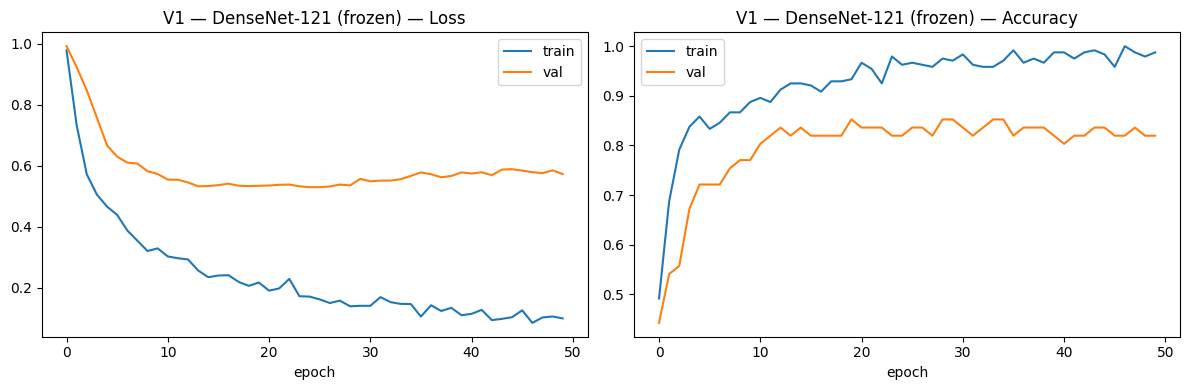

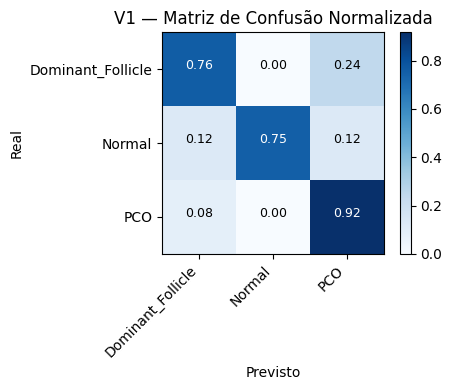

                   precision    recall  f1-score   support

Dominant_Follicle       0.88      0.76      0.81        29
           Normal       1.00      0.75      0.86         8
              PCO       0.73      0.92      0.81        24

         accuracy                           0.82        61
        macro avg       0.87      0.81      0.83        61
     weighted avg       0.84      0.82      0.82        61



In [10]:
plot_curves(hist_v1, "V1 — DenseNet-121 (frozen)")
plot_cm(yt_v1, yp_v1, CLASS_NAMES, "V1", normalize=True)
print(classification_report(yt_v1, yp_v1, target_names=CLASS_NAMES))


> **Observação V1:** *(preencher após execução)*

---
## V2 · Muito Leve — DenseNet-169 (100% congelado)

| Parâmetro | Valor |
|---|---|
| Backbone | DenseNet-169, ImageNet, 100% congelado |
| Cabeça | BN + FC |
| Augmentation | Flip H |
| Scheduler | Nenhum |
| Épocas | 12 |
| Resolução | 224 |
| LR | 1e-3 |

**Objetivo:** backbone mais largo — comparar com V1.


In [11]:
def build_v2():
    weights = DenseNet169_Weights.IMAGENET1K_V1
    model = densenet169(weights=weights)
    for p in model.parameters():
        p.requires_grad = False
    in_feats = model.classifier.in_features
    model.classifier = nn.Sequential(
        nn.BatchNorm1d(in_feats),
        nn.Linear(in_feats, NUM_CLASSES),
    )
    return model.to(device)

train_tfms_v2, val_tfms_v2 = get_transforms("minimal", img_size=224)
train_loader_v2, val_loader_v2 = make_loaders(train_tfms_v2, val_tfms_v2, batch_size=24)

model_v2 = build_v2()
print(f"Parâmetros treináveis: {sum(p.numel() for p in model_v2.parameters() if p.requires_grad):,}")


Downloading: "https://download.pytorch.org/models/densenet169-b2777c0a.pth" to C:\Users\brian/.cache\torch\hub\checkpoints\densenet169-b2777c0a.pth
100%|██████████| 54.7M/54.7M [00:00<00:00, 93.5MB/s]


Parâmetros treináveis: 8,323


In [12]:
print("\n=== Treinando V2 ===")
model_v2, hist_v2, res_v2, yt_v2, yp_v2 = train_model(
    model_v2, train_loader_v2, val_loader_v2,
    epochs=1000,
    lr=1e-3,
    var_name="V2 DN-169 frozen",
)
res_v2["backbone"] = "DenseNet-169 (frozen)"
ALL_RESULTS.append(res_v2)
show_results(res_v2)

save_model(model_v2, res_v2["variacao"])


=== Treinando V2 ===
  [  1/1000] loss 0.9443/0.8607  acc 0.4958/0.5902  f1_val 0.6348
  [  2/1000] loss 0.5877/0.7252  acc 0.7833/0.7377  f1_val 0.7526
  [  3/1000] loss 0.4580/0.6176  acc 0.8375/0.7869  f1_val 0.7879
  [  4/1000] loss 0.4177/0.5691  acc 0.8417/0.7869  f1_val 0.7863
  [  5/1000] loss 0.3907/0.5296  acc 0.8417/0.8361  f1_val 0.8251
  [  6/1000] loss 0.3107/0.5130  acc 0.8792/0.8361  f1_val 0.8261
  [  7/1000] loss 0.2648/0.4961  acc 0.9292/0.8361  f1_val 0.8237
  [  8/1000] loss 0.2622/0.5006  acc 0.9375/0.8033  f1_val 0.8010
  [  9/1000] loss 0.2702/0.4907  acc 0.9250/0.8033  f1_val 0.7981
  [ 10/1000] loss 0.2542/0.4690  acc 0.9208/0.8197  f1_val 0.8130
  [ 11/1000] loss 0.2086/0.4638  acc 0.9708/0.8689  f1_val 0.8519
  [ 12/1000] loss 0.2212/0.4490  acc 0.9333/0.8525  f1_val 0.8382
  [ 13/1000] loss 0.1937/0.4502  acc 0.9458/0.8525  f1_val 0.8382
  [ 14/1000] loss 0.1916/0.4580  acc 0.9500/0.8525  f1_val 0.8391
  [ 15/1000] loss 0.1676/0.4651  acc 0.9750/0.8525  f1

WindowsPath('modelos_salvos/membro3/membro3_V2_DN-169_frozen.joblib')

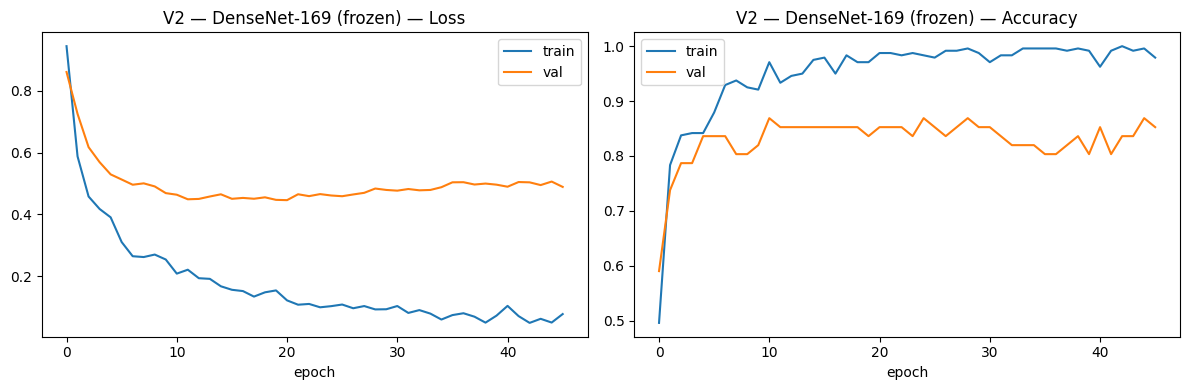

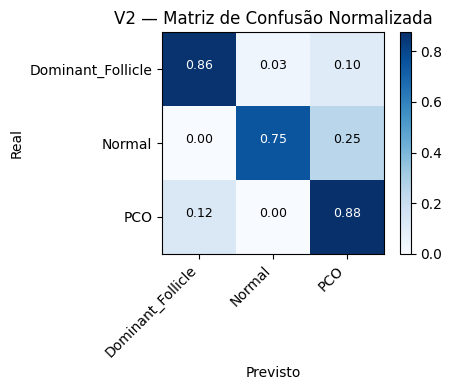

                   precision    recall  f1-score   support

Dominant_Follicle       0.89      0.86      0.88        29
           Normal       0.86      0.75      0.80         8
              PCO       0.81      0.88      0.84        24

         accuracy                           0.85        61
        macro avg       0.85      0.83      0.84        61
     weighted avg       0.85      0.85      0.85        61



In [13]:
plot_curves(hist_v2, "V2 — DenseNet-169 (frozen)")
plot_cm(yt_v2, yp_v2, CLASS_NAMES, "V2", normalize=True)
print(classification_report(yt_v2, yp_v2, target_names=CLASS_NAMES))


> **Observação V2:** *(preencher após execução)*

---
## V3 · Leve — DenseNet-121 (DenseBlock 4 livre)

| Parâmetro | Valor |
|---|---|
| Backbone | DenseNet-121 — DenseBlock 4 + norm5 livres |
| Cabeça | BN + FC(512) + Dropout(0.3) + FC |
| Augmentation | Flip H/V + Rotação ±15° |
| Scheduler | Nenhum |
| Épocas | 22 |
| Resolução | 224 |
| LR | 1e-4 |

**Objetivo:** primeiro fine-tuning sutil — DenseBlock 4 (último) livre.


In [14]:
def build_v3():
    weights = DenseNet121_Weights.IMAGENET1K_V1
    model = densenet121(weights=weights)
    for p in model.parameters():
        p.requires_grad = False
    for p in model.features.denseblock4.parameters():
        p.requires_grad = True
    for p in model.features.norm5.parameters():
        p.requires_grad = True
    in_feats = model.classifier.in_features
    model.classifier = nn.Sequential(
        nn.BatchNorm1d(in_feats),
        nn.Linear(in_feats, 512),
        nn.ReLU(inplace=True),
        nn.Dropout(0.3),
        nn.Linear(512, NUM_CLASSES),
    )
    return model.to(device)

train_tfms_v3, val_tfms_v3 = get_transforms("light", img_size=224)
train_loader_v3, val_loader_v3 = make_loaders(train_tfms_v3, val_tfms_v3, batch_size=32)

model_v3 = build_v3()
print(f"Parâmetros treináveis: {sum(p.numel() for p in model_v3.parameters() if p.requires_grad):,}")


Parâmetros treináveis: 2,688,515


In [15]:
print("\n=== Treinando V3 ===")
model_v3, hist_v3, res_v3, yt_v3, yp_v3 = train_model(
    model_v3, train_loader_v3, val_loader_v3,
    epochs=1000,
    lr=1e-4,
    var_name="V3 DN-121 block4",
)
res_v3["backbone"] = "DN-121 (block4)"
ALL_RESULTS.append(res_v3)
show_results(res_v3)

save_model(model_v3, res_v3["variacao"])


=== Treinando V3 ===
  [  1/1000] loss 1.0600/0.9612  acc 0.4542/0.4754  f1_val 0.3983
  [  2/1000] loss 0.8792/0.9060  acc 0.6167/0.5738  f1_val 0.5939
  [  3/1000] loss 0.7856/0.8493  acc 0.6542/0.6066  f1_val 0.6299
  [  4/1000] loss 0.7036/0.7884  acc 0.7500/0.6393  f1_val 0.6722
  [  5/1000] loss 0.6265/0.6826  acc 0.7833/0.8361  f1_val 0.8409
  [  6/1000] loss 0.5582/0.5987  acc 0.8042/0.8197  f1_val 0.8282
  [  7/1000] loss 0.5093/0.5566  acc 0.8042/0.8033  f1_val 0.8154
  [  8/1000] loss 0.4565/0.5290  acc 0.8333/0.8525  f1_val 0.8535
  [  9/1000] loss 0.4320/0.4798  acc 0.8417/0.8525  f1_val 0.8535
  [ 10/1000] loss 0.4177/0.4434  acc 0.8250/0.8361  f1_val 0.8409
  [ 11/1000] loss 0.3742/0.4268  acc 0.8750/0.8525  f1_val 0.8536
  [ 12/1000] loss 0.3550/0.4289  acc 0.8625/0.8689  f1_val 0.8659
  [ 13/1000] loss 0.2953/0.4451  acc 0.9042/0.8525  f1_val 0.8535
  [ 14/1000] loss 0.2960/0.4337  acc 0.8875/0.8525  f1_val 0.8535
  [ 15/1000] loss 0.3001/0.4060  acc 0.9167/0.8525  f1

WindowsPath('modelos_salvos/membro3/membro3_V3_DN-121_block4.joblib')

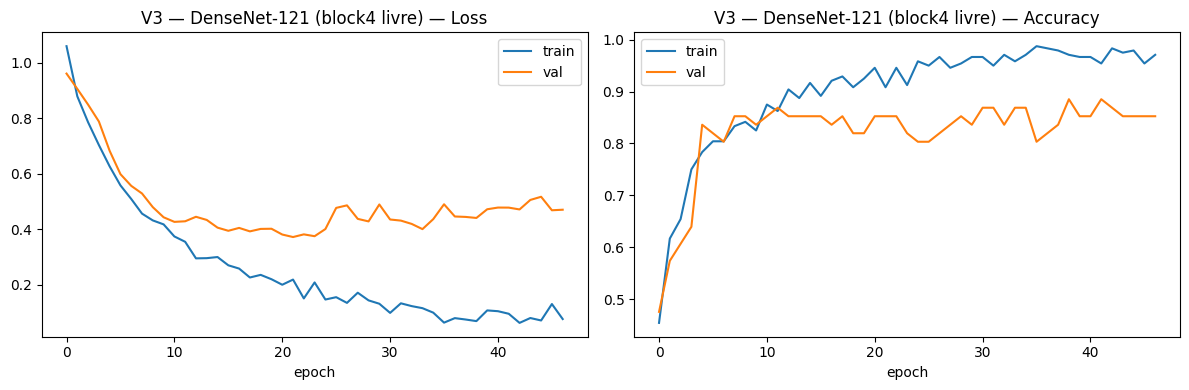

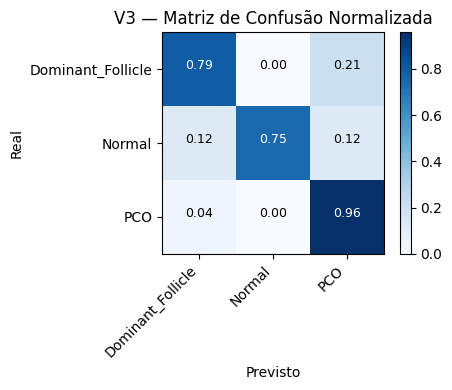

                   precision    recall  f1-score   support

Dominant_Follicle       0.92      0.79      0.85        29
           Normal       1.00      0.75      0.86         8
              PCO       0.77      0.96      0.85        24

         accuracy                           0.85        61
        macro avg       0.90      0.83      0.85        61
     weighted avg       0.87      0.85      0.85        61



In [16]:
plot_curves(hist_v3, "V3 — DenseNet-121 (block4 livre)")
plot_cm(yt_v3, yp_v3, CLASS_NAMES, "V3", normalize=True)
print(classification_report(yt_v3, yp_v3, target_names=CLASS_NAMES))


> **Observação V3:** *(preencher após execução)*

---
## V4 · Leve — DenseNet-121 (DenseBlock 4 + Scheduler)

| Parâmetro | Valor |
|---|---|
| Backbone | DenseNet-121 — DenseBlock 4 + norm5 livres |
| Cabeça | BN + FC(512) + Dropout(0.4) + FC |
| Augmentation | Flip + Rot + ColorJitter leve |
| Scheduler | ReduceLROnPlateau (patience=4) |
| Épocas | 25 |
| Resolução | 224 |
| LR | 1e-4 |

**Objetivo:** scheduler entra pela 1ª vez.


In [17]:
def build_v4():
    weights = DenseNet121_Weights.IMAGENET1K_V1
    model = densenet121(weights=weights)
    for p in model.parameters():
        p.requires_grad = False
    for p in model.features.denseblock4.parameters():
        p.requires_grad = True
    for p in model.features.norm5.parameters():
        p.requires_grad = True
    in_feats = model.classifier.in_features
    model.classifier = nn.Sequential(
        nn.BatchNorm1d(in_feats),
        nn.Linear(in_feats, 512),
        nn.ReLU(inplace=True),
        nn.Dropout(0.4),
        nn.Linear(512, NUM_CLASSES),
    )
    return model.to(device)

train_tfms_v4, val_tfms_v4 = get_transforms("light_jitter", img_size=224)
train_loader_v4, val_loader_v4 = make_loaders(train_tfms_v4, val_tfms_v4, batch_size=32)

model_v4 = build_v4()
print(f"Parâmetros treináveis: {sum(p.numel() for p in model_v4.parameters() if p.requires_grad):,}")


Parâmetros treináveis: 2,688,515


In [18]:
print("\n=== Treinando V4 ===")
model_v4, hist_v4, res_v4, yt_v4, yp_v4 = train_model(
    model_v4, train_loader_v4, val_loader_v4,
    epochs=1000,
    lr=1e-4,
    scheduler_fn=lambda opt: torch.optim.lr_scheduler.ReduceLROnPlateau(opt, mode='min', patience=4, factor=0.5),
    var_name="V4 DN-121 +Scheduler",
)
res_v4["backbone"] = "DN-121 (block4+Sched)"
ALL_RESULTS.append(res_v4)
show_results(res_v4)

save_model(model_v4, res_v4["variacao"])


=== Treinando V4 ===
  [  1/1000] loss 1.0340/0.9320  acc 0.4958/0.5410  f1_val 0.4786
  [  2/1000] loss 0.8578/0.8777  acc 0.6208/0.6557  f1_val 0.6454
  [  3/1000] loss 0.7623/0.8189  acc 0.6792/0.6557  f1_val 0.6413
  [  4/1000] loss 0.6858/0.7355  acc 0.7750/0.7541  f1_val 0.7629
  [  5/1000] loss 0.6301/0.6632  acc 0.7583/0.8033  f1_val 0.8082
  [  6/1000] loss 0.5902/0.6128  acc 0.8000/0.8525  f1_val 0.8524
  [  7/1000] loss 0.5226/0.5707  acc 0.8042/0.8033  f1_val 0.8127
  [  8/1000] loss 0.4863/0.5328  acc 0.8375/0.8197  f1_val 0.8262
  [  9/1000] loss 0.4614/0.5060  acc 0.8500/0.8525  f1_val 0.8531
  [ 10/1000] loss 0.4081/0.4714  acc 0.8583/0.9016  f1_val 0.8905
  [ 11/1000] loss 0.4100/0.4429  acc 0.8417/0.8852  f1_val 0.8782
  [ 12/1000] loss 0.3540/0.4180  acc 0.8542/0.8689  f1_val 0.8659
  [ 13/1000] loss 0.3739/0.4240  acc 0.8458/0.8361  f1_val 0.8412
  [ 14/1000] loss 0.3700/0.4317  acc 0.8417/0.8361  f1_val 0.8416
  [ 15/1000] loss 0.3469/0.4299  acc 0.8750/0.8361  f1

WindowsPath('modelos_salvos/membro3/membro3_V4_DN-121_+Scheduler.joblib')

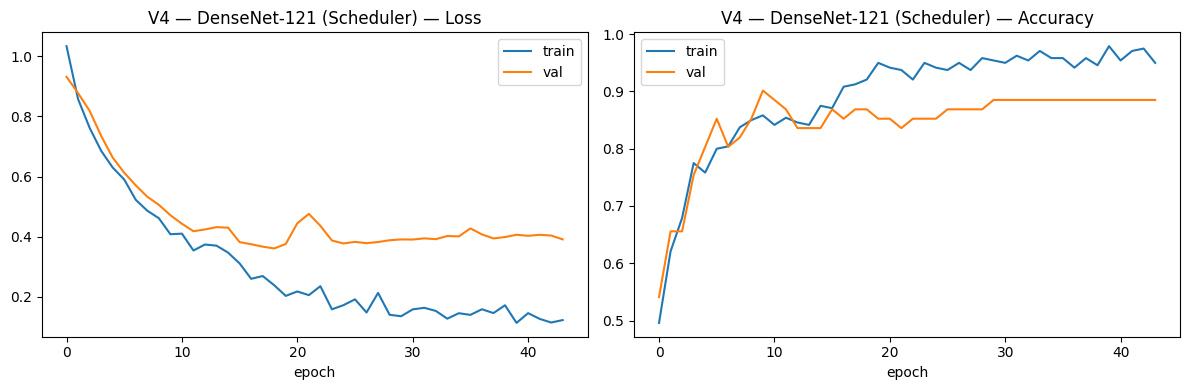

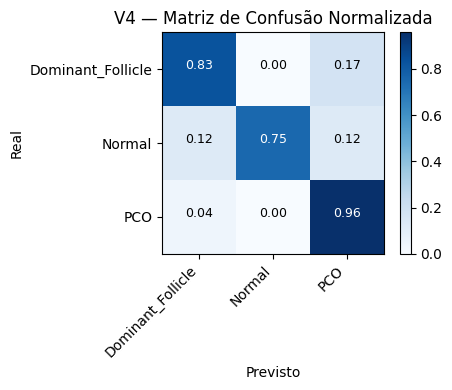

                   precision    recall  f1-score   support

Dominant_Follicle       0.92      0.83      0.87        29
           Normal       1.00      0.75      0.86         8
              PCO       0.79      0.96      0.87        24

         accuracy                           0.87        61
        macro avg       0.91      0.85      0.87        61
     weighted avg       0.88      0.87      0.87        61



In [19]:
plot_curves(hist_v4, "V4 — DenseNet-121 (Scheduler)")
plot_cm(yt_v4, yp_v4, CLASS_NAMES, "V4", normalize=True)
print(classification_report(yt_v4, yp_v4, target_names=CLASS_NAMES))


> **Observação V4:** *(preencher após execução)*

---
## V5 · Médio — DenseNet-121 (DenseBlocks 3+4 livres)

| Parâmetro | Valor |
|---|---|
| Backbone | DenseNet-121 — DenseBlock 3 + DenseBlock 4 + transition3 + norm5 livres |
| Cabeça | BN + FC(768) + BN + Dropout(0.4) + FC |
| Augmentation | Flip + Rot + Jitter + Blur |
| Scheduler | ReduceLROnPlateau (patience=5) |
| Épocas | 35 |
| Resolução | 224 |
| LR | 5e-5 |

**Objetivo:** 2 DenseBlocks livres — observar reutilização de features.


In [20]:
def build_v5():
    weights = DenseNet121_Weights.IMAGENET1K_V1
    model = densenet121(weights=weights)
    for p in model.parameters():
        p.requires_grad = False
    for p in model.features.denseblock3.parameters():
        p.requires_grad = True
    for p in model.features.transition3.parameters():
        p.requires_grad = True
    for p in model.features.denseblock4.parameters():
        p.requires_grad = True
    for p in model.features.norm5.parameters():
        p.requires_grad = True
    in_feats = model.classifier.in_features
    model.classifier = nn.Sequential(
        nn.BatchNorm1d(in_feats),
        nn.Linear(in_feats, 768),
        nn.BatchNorm1d(768),
        nn.ReLU(inplace=True),
        nn.Dropout(0.4),
        nn.Linear(768, NUM_CLASSES),
    )
    return model.to(device)

train_tfms_v5, val_tfms_v5 = get_transforms("moderate", img_size=224)
train_loader_v5, val_loader_v5 = make_loaders(train_tfms_v5, val_tfms_v5, batch_size=24)

model_v5 = build_v5()
print(f"Parâmetros treináveis: {sum(p.numel() for p in model_v5.parameters() if p.requires_grad):,}")


Parâmetros treináveis: 6,317,315


In [21]:
print("\n=== Treinando V5 ===")
model_v5, hist_v5, res_v5, yt_v5, yp_v5 = train_model(
    model_v5, train_loader_v5, val_loader_v5,
    epochs=1000,
    lr=5e-5,
    scheduler_fn=lambda opt: torch.optim.lr_scheduler.ReduceLROnPlateau(opt, mode='min', patience=5, factor=0.5),
    var_name="V5 DN-121 blocks3+4",
)
res_v5["backbone"] = "DN-121 (block3+4)"
ALL_RESULTS.append(res_v5)
show_results(res_v5)

save_model(model_v5, res_v5["variacao"])


=== Treinando V5 ===
  [  1/1000] loss 1.0830/1.0356  acc 0.3833/0.5082  f1_val 0.4059
  [  2/1000] loss 0.8549/0.9392  acc 0.5958/0.6393  f1_val 0.5927
  [  3/1000] loss 0.7495/0.7940  acc 0.6583/0.7705  f1_val 0.7630
  [  4/1000] loss 0.6365/0.6677  acc 0.7750/0.7377  f1_val 0.7441
  [  5/1000] loss 0.5869/0.5934  acc 0.7833/0.8197  f1_val 0.8287
  [  6/1000] loss 0.4967/0.5089  acc 0.8625/0.8361  f1_val 0.8413
  [  7/1000] loss 0.4526/0.4575  acc 0.8250/0.8689  f1_val 0.8646
  [  8/1000] loss 0.4239/0.4058  acc 0.8583/0.8689  f1_val 0.8635
  [  9/1000] loss 0.3279/0.3647  acc 0.8750/0.8852  f1_val 0.8765
  [ 10/1000] loss 0.3239/0.3297  acc 0.8792/0.9016  f1_val 0.8901
  [ 11/1000] loss 0.2962/0.3325  acc 0.8958/0.9180  f1_val 0.9028
  [ 12/1000] loss 0.2901/0.3273  acc 0.9000/0.9180  f1_val 0.9028
  [ 13/1000] loss 0.2600/0.3082  acc 0.9208/0.9180  f1_val 0.9028
  [ 14/1000] loss 0.2563/0.3190  acc 0.9208/0.9180  f1_val 0.9028
  [ 15/1000] loss 0.2179/0.3199  acc 0.9250/0.9180  f1

WindowsPath('modelos_salvos/membro3/membro3_V5_DN-121_blocks3+4.joblib')

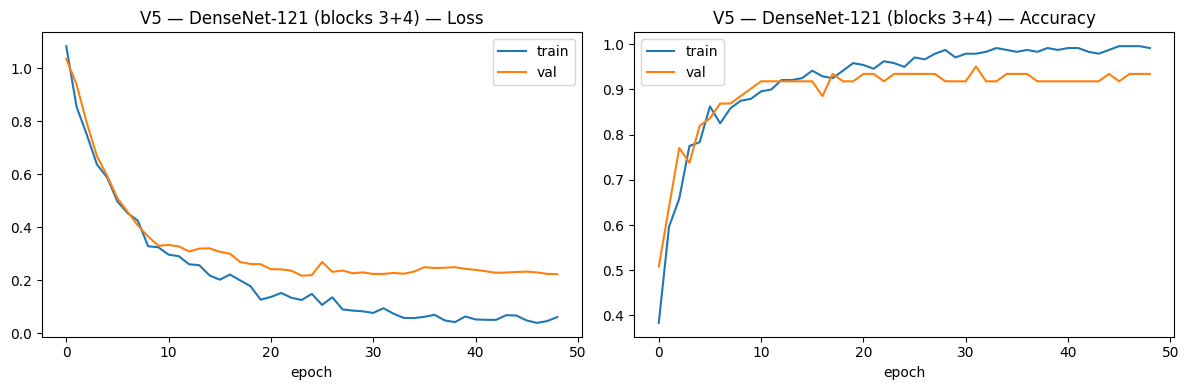

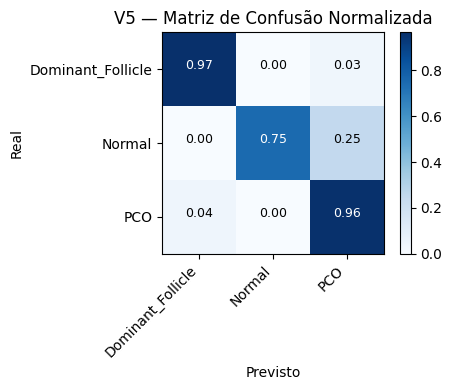

                   precision    recall  f1-score   support

Dominant_Follicle       0.97      0.97      0.97        29
           Normal       1.00      0.75      0.86         8
              PCO       0.88      0.96      0.92        24

         accuracy                           0.93        61
        macro avg       0.95      0.89      0.91        61
     weighted avg       0.94      0.93      0.93        61



In [22]:
plot_curves(hist_v5, "V5 — DenseNet-121 (blocks 3+4)")
plot_cm(yt_v5, yp_v5, CLASS_NAMES, "V5", normalize=True)
print(classification_report(yt_v5, yp_v5, target_names=CLASS_NAMES))


> **Observação V5:** *(preencher após execução)*

---
## V6 · Médio — DenseNet-169 (DenseBlocks 3+4 livres, 256px)

| Parâmetro | Valor |
|---|---|
| Backbone | **DenseNet-169** — DenseBlock 3 + 4 + transition3 + norm5 livres |
| Cabeça | BN + FC(1024) + BN + Dropout(0.45) + FC |
| Augmentation | Flip + Rot + Jitter + Blur |
| Scheduler | StepLR (γ=0.5, step=10) |
| Épocas | 40 |
| Resolução | **256** |
| LR | 5e-5 |

**Objetivo:** backbone mais largo (169) com resolução maior.


In [23]:
def build_v6():
    weights = DenseNet169_Weights.IMAGENET1K_V1
    model = densenet169(weights=weights)
    for p in model.parameters():
        p.requires_grad = False
    for p in model.features.denseblock3.parameters():
        p.requires_grad = True
    for p in model.features.transition3.parameters():
        p.requires_grad = True
    for p in model.features.denseblock4.parameters():
        p.requires_grad = True
    for p in model.features.norm5.parameters():
        p.requires_grad = True
    in_feats = model.classifier.in_features
    model.classifier = nn.Sequential(
        nn.BatchNorm1d(in_feats),
        nn.Linear(in_feats, 1024),
        nn.BatchNorm1d(1024),
        nn.ReLU(inplace=True),
        nn.Dropout(0.45),
        nn.Linear(1024, NUM_CLASSES),
    )
    return model.to(device)

train_tfms_v6, val_tfms_v6 = get_transforms("moderate", img_size=256)
train_loader_v6, val_loader_v6 = make_loaders(train_tfms_v6, val_tfms_v6, batch_size=16)

model_v6 = build_v6()
print(f"Parâmetros treináveis: {sum(p.numel() for p in model_v6.parameters() if p.requires_grad):,}")


Parâmetros treináveis: 12,768,259


In [24]:
print("\n=== Treinando V6 ===")
model_v6, hist_v6, res_v6, yt_v6, yp_v6 = train_model(
    model_v6, train_loader_v6, val_loader_v6,
    epochs=1000,
    lr=5e-5,
    scheduler_fn=lambda opt: torch.optim.lr_scheduler.StepLR(opt, step_size=10, gamma=0.5),
    var_name="V6 DN-169 256px",
)
res_v6["backbone"] = "DN-169 (block3+4, 256)"
ALL_RESULTS.append(res_v6)
show_results(res_v6)

save_model(model_v6, res_v6["variacao"])


=== Treinando V6 ===
  [  1/1000] loss 0.9667/0.9356  acc 0.4750/0.5902  f1_val 0.5291
  [  2/1000] loss 0.7426/0.6533  acc 0.6500/0.7377  f1_val 0.7410
  [  3/1000] loss 0.5864/0.4743  acc 0.7458/0.8197  f1_val 0.8115
  [  4/1000] loss 0.4658/0.3683  acc 0.8250/0.8689  f1_val 0.8645
  [  5/1000] loss 0.3599/0.3409  acc 0.8667/0.8852  f1_val 0.8774
  [  6/1000] loss 0.3360/0.3131  acc 0.8750/0.9016  f1_val 0.8774
  [  7/1000] loss 0.2767/0.2961  acc 0.9167/0.8689  f1_val 0.8521
  [  8/1000] loss 0.2838/0.2779  acc 0.8833/0.8852  f1_val 0.8648
  [  9/1000] loss 0.2437/0.2603  acc 0.9042/0.9180  f1_val 0.9029
  [ 10/1000] loss 0.2195/0.2280  acc 0.9208/0.9508  f1_val 0.9150
  [ 11/1000] loss 0.2252/0.2182  acc 0.9292/0.9508  f1_val 0.9150
  [ 12/1000] loss 0.2082/0.2346  acc 0.9250/0.9344  f1_val 0.9025
  [ 13/1000] loss 0.1719/0.2165  acc 0.9542/0.9508  f1_val 0.9150
  [ 14/1000] loss 0.1650/0.2203  acc 0.9542/0.9344  f1_val 0.9025
  [ 15/1000] loss 0.1455/0.2040  acc 0.9625/0.9344  f1

WindowsPath('modelos_salvos/membro3/membro3_V6_DN-169_256px.joblib')

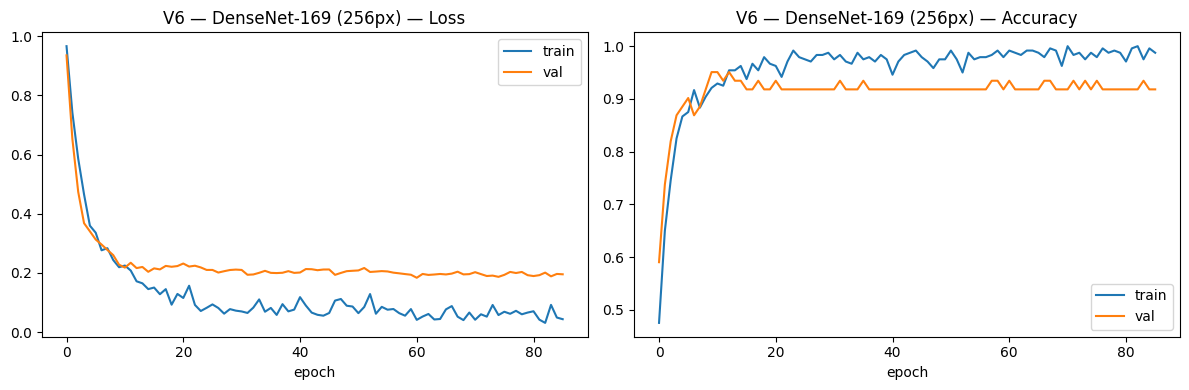

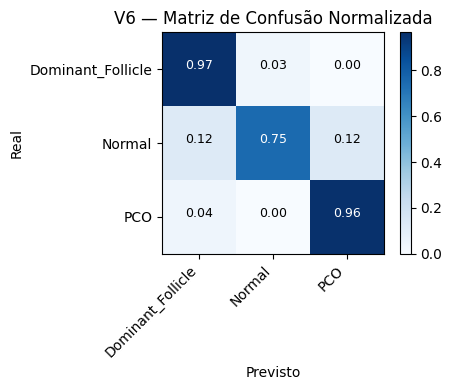

                   precision    recall  f1-score   support

Dominant_Follicle       0.93      0.97      0.95        29
           Normal       0.86      0.75      0.80         8
              PCO       0.96      0.96      0.96        24

         accuracy                           0.93        61
        macro avg       0.92      0.89      0.90        61
     weighted avg       0.93      0.93      0.93        61



In [25]:
plot_curves(hist_v6, "V6 — DenseNet-169 (256px)")
plot_cm(yt_v6, yp_v6, CLASS_NAMES, "V6", normalize=True)
print(classification_report(yt_v6, yp_v6, target_names=CLASS_NAMES))


> **Observação V6:** *(preencher após execução)*

---
## V7/V8 · Pesado — Helpers CutMix

In [26]:
import torch.nn.functional as F

def rand_bbox(size, lam):
    W, H = size[2], size[3]
    cut_rat = np.sqrt(1 - lam)
    cut_w, cut_h = int(W * cut_rat), int(H * cut_rat)
    cx, cy = np.random.randint(W), np.random.randint(H)
    bbx1 = np.clip(cx - cut_w // 2, 0, W)
    bby1 = np.clip(cy - cut_h // 2, 0, H)
    bbx2 = np.clip(cx + cut_w // 2, 0, W)
    bby2 = np.clip(cy + cut_h // 2, 0, H)
    return bbx1, bby1, bbx2, bby2

def cutmix_data(x, y, alpha=0.4):
    """CutMix simples: retorna x_mix, y_a, y_b, lam."""
    lam = np.random.beta(alpha, alpha)
    rand_idx = torch.randperm(x.size(0)).to(device)
    y_a, y_b = y, y[rand_idx]
    bbx1, bby1, bbx2, bby2 = rand_bbox(x.size(), lam)
    x_mix = x.clone()
    x_mix[:, :, bbx1:bbx2, bby1:bby2] = x[rand_idx, :, bbx1:bbx2, bby1:bby2]
    lam = 1 - (bbx2-bbx1)*(bby2-bby1) / (x.size(-1)*x.size(-2))
    return x_mix, y_a, y_b, lam

def train_cutmix_epoch(model, loader, optimizer, criterion, cutmix_prob=0.5):
    """Época com CutMix aplicado com probabilidade cutmix_prob."""
    model.train()
    total_loss, total_correct, total = 0.0, 0, 0
    all_preds, all_targets = [], []
    for X, y in loader:
        X, y = X.to(device), y.to(device)
        optimizer.zero_grad()
        if np.random.rand() < cutmix_prob:
            X_mix, y_a, y_b, lam = cutmix_data(X, y)
            logits = model(X_mix)
            loss = lam * criterion(logits, y_a) + (1-lam) * criterion(logits, y_b)
        else:
            logits = model(X)
            loss = criterion(logits, y)
        loss.backward(); optimizer.step()
        preds = logits.argmax(1)
        total_loss    += loss.item() * y.size(0)
        total_correct += (preds == y).sum().item()
        total         += y.size(0)
        all_preds.append(preds.detach().cpu().numpy())
        all_targets.append(y.detach().cpu().numpy())
    avg_loss = total_loss / total
    acc      = total_correct / total
    y_true   = np.concatenate(all_targets)
    y_pred   = np.concatenate(all_preds)
    f1       = f1_score(y_true, y_pred, average="macro", zero_division=0)
    return avg_loss, acc, f1, y_true, y_pred

print("✅ Funções CutMix prontas")


✅ Funções CutMix prontas


---
## V7 · Pesado — DenseNet-121 (FT completo + TTA)

| Parâmetro | Valor |
|---|---|
| Backbone | DenseNet-121 — **FT completo** (LR diff: backbone 1e-5 / cabeça 1e-4) |
| Cabeça | BN + FC(1024) + BN + Dropout(0.5) + FC |
| Augmentation | CutMix + RandomErasing |
| Scheduler | CosineAnnealingLR |
| Épocas | 50 |
| Resolução | 256 |
| Extras | WD=1e-4, Label Smoothing 0.1, TTA |

**Objetivo:** FT completo no DN-121 com regularização forte.


In [27]:
def build_v7():
    weights = DenseNet121_Weights.IMAGENET1K_V1
    model = densenet121(weights=weights)
    for p in model.parameters():
        p.requires_grad = True
    in_feats = model.classifier.in_features
    model.classifier = nn.Sequential(
        nn.BatchNorm1d(in_feats),
        nn.Linear(in_feats, 1024),
        nn.BatchNorm1d(1024),
        nn.ReLU(inplace=True),
        nn.Dropout(0.5),
        nn.Linear(1024, NUM_CLASSES),
    )
    return model.to(device)

train_tfms_v7, val_tfms_v7 = get_transforms("heavy", img_size=256)
train_loader_v7, val_loader_v7 = make_loaders(train_tfms_v7, val_tfms_v7, batch_size=16)

model_v7 = build_v7()
print(f"Parâmetros treináveis: {sum(p.numel() for p in model_v7.parameters() if p.requires_grad):,}")


Parâmetros treináveis: 8,010,627


In [28]:
EPOCHS_V7 = 50
criterion_v7 = nn.CrossEntropyLoss(label_smoothing=0.1)
optimizer_v7 = torch.optim.AdamW([
    {"params": model_v7.features.parameters(), "lr": 1e-05},
    {"params": model_v7.classifier.parameters(),     "lr": 0.0001},
], weight_decay=0.0001)
scheduler_v7 = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer_v7, T_max=EPOCHS_V7, eta_min=1e-7)

print("\n=== Treinando V7 (FT completo) ===")
history_v7 = {k: [] for k in ["train_loss","val_loss","train_acc","val_acc","val_f1"]}
best_f1_v7, best_state_v7 = 0.0, None
yt_v7, yp_v7 = None, None
t0_v7 = time.time()

for e in range(1, EPOCHS_V7 + 1):
    tr_loss, tr_acc, _, _, _       = train_cutmix_epoch(model_v7, train_loader_v7, optimizer_v7, criterion_v7)
    va_loss, va_acc, va_f1, yt, yp = run_epoch(model_v7, val_loader_v7, optimizer_v7, criterion_v7, train=False)
    scheduler_v7.step()

    for k, v in zip(history_v7.keys(), [tr_loss, va_loss, tr_acc, va_acc, va_f1]):
        history_v7[k].append(v)
    if va_f1 > best_f1_v7:
        best_f1_v7, best_state_v7 = va_f1, deepcopy(model_v7.state_dict())
        yt_v7, yp_v7 = yt, yp
    print(f"  [{e:>3}/{EPOCHS_V7}] loss {tr_loss:.4f}/{va_loss:.4f}  acc {tr_acc:.4f}/{va_acc:.4f}  f1 {va_f1:.4f}")

model_v7.load_state_dict(best_state_v7)
elapsed_v7 = (time.time() - t0_v7) / 60

print("  → Aplicando TTA...")
tta_acc_v7, tta_f1_v7, yt_v7, yp_v7 = tta_predict(model_v7, val_loader_v7, img_size=256)
print(f"  TTA  acc={tta_acc_v7:.4f}  f1={tta_f1_v7:.4f}")

res_v7 = {
    "variacao": "V7 DN-121 FT+TTA",
    "backbone": "DN-121 (FT completo, TTA)",
    "accuracy": round(tta_acc_v7, 4),
    "f1_macro": round(tta_f1_v7,  4),
    "precision": round(precision_score(yt_v7, yp_v7, average="macro", zero_division=0), 4),
    "recall":    round(recall_score(yt_v7, yp_v7, average="macro", zero_division=0), 4),
    "loss":      round(history_v7["val_loss"][-1], 4),
    "tempo_min": round(elapsed_v7, 1),
}
ALL_RESULTS.append(res_v7)
show_results(res_v7)

save_model(model_v7, res_v7["variacao"])



=== Treinando V7 (FT completo) ===
  [  1/50] loss 1.0301/0.9734  acc 0.4583/0.4590  f1 0.5118
  [  2/50] loss 0.9000/0.8493  acc 0.5917/0.6393  f1 0.6909
  [  3/50] loss 0.8469/0.8096  acc 0.6167/0.6721  f1 0.7077
  [  4/50] loss 0.8103/0.7853  acc 0.6292/0.7377  f1 0.7671
  [  5/50] loss 0.8051/0.7611  acc 0.6583/0.7377  f1 0.7665
  [  6/50] loss 0.8201/0.7462  acc 0.6417/0.7869  f1 0.8018
  [  7/50] loss 0.7710/0.7140  acc 0.6500/0.7705  f1 0.7901
  [  8/50] loss 0.7847/0.6997  acc 0.6542/0.7705  f1 0.7919
  [  9/50] loss 0.7765/0.6643  acc 0.6833/0.8361  f1 0.8403
  [ 10/50] loss 0.7526/0.6362  acc 0.6792/0.8689  f1 0.8646
  [ 11/50] loss 0.7879/0.6433  acc 0.6500/0.8361  f1 0.8416
  [ 12/50] loss 0.7465/0.6219  acc 0.7125/0.8361  f1 0.8416
  [ 13/50] loss 0.6864/0.6033  acc 0.7292/0.8689  f1 0.8652
  [ 14/50] loss 0.7434/0.5968  acc 0.7042/0.8852  f1 0.8774
  [ 15/50] loss 0.7637/0.5886  acc 0.7083/0.8852  f1 0.8774
  [ 16/50] loss 0.7418/0.5954  acc 0.6958/0.8689  f1 0.8654
  [ 

WindowsPath('modelos_salvos/membro3/membro3_V7_DN-121_FT+TTA.joblib')

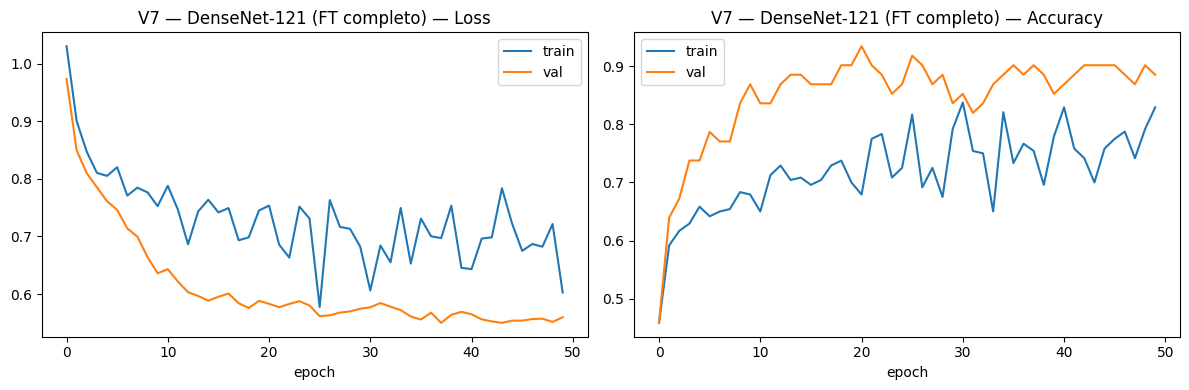

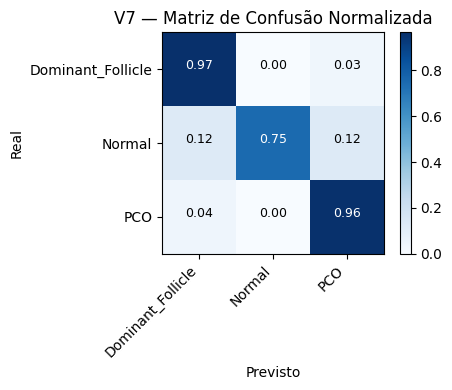

                   precision    recall  f1-score   support

Dominant_Follicle       0.93      0.97      0.95        29
           Normal       1.00      0.75      0.86         8
              PCO       0.92      0.96      0.94        24

         accuracy                           0.93        61
        macro avg       0.95      0.89      0.92        61
     weighted avg       0.94      0.93      0.93        61



In [29]:
plot_curves(history_v7, "V7 — DenseNet-121 (FT completo)")
plot_cm(yt_v7, yp_v7, CLASS_NAMES, "V7", normalize=True)
print(classification_report(yt_v7, yp_v7, target_names=CLASS_NAMES))


> **Observação V7:** *(preencher após execução)*

---
## V8 · Pesado — DenseNet-169 (FT completo + RandAugment + Label Smoothing)

| Parâmetro | Valor |
|---|---|
| Backbone | **DenseNet-169** — FT completo (LR diff) |
| Cabeça | BN + FC(1024) + BN + Dropout(0.5) + FC |
| Augmentation | RandAugment + CutMix |
| Scheduler | CosineAnnealingWarmRestarts |
| Épocas | 60 |
| Resolução | **299** |
| Extras | Label Smoothing 0.1, WD=1e-4, TTA |

**Objetivo:** principal candidato ao ensemble — DN-169 com regularização máxima.


In [30]:
def build_v8():
    weights = DenseNet169_Weights.IMAGENET1K_V1
    model = densenet169(weights=weights)
    for p in model.parameters():
        p.requires_grad = True
    in_feats = model.classifier.in_features
    model.classifier = nn.Sequential(
        nn.BatchNorm1d(in_feats),
        nn.Linear(in_feats, 1024),
        nn.BatchNorm1d(1024),
        nn.ReLU(inplace=True),
        nn.Dropout(0.5),
        nn.Linear(1024, NUM_CLASSES),
    )
    return model.to(device)

def get_transforms_randaugment(img_size=299):
    normalize = transforms.Normalize(IMAGENET_MEAN, IMAGENET_STD)
    train_tfms = transforms.Compose([
        transforms.Resize((img_size, img_size)),
        transforms.RandAugment(num_ops=2, magnitude=9),
        transforms.RandomHorizontalFlip(),
        transforms.ToTensor(),
        normalize,
        transforms.RandomErasing(p=0.3, scale=(0.02, 0.2)),
    ])
    val_tfms = transforms.Compose([
        transforms.Resize((img_size, img_size)),
        transforms.ToTensor(),
        normalize,
    ])
    return train_tfms, val_tfms

train_tfms_v8, val_tfms_v8 = get_transforms_randaugment(img_size=299)
train_loader_v8, val_loader_v8 = make_loaders(train_tfms_v8, val_tfms_v8, batch_size=12)

model_v8 = build_v8()
print(f"Parâmetros treináveis: {sum(p.numel() for p in model_v8.parameters() if p.requires_grad):,}")


Parâmetros treináveis: 14,197,891


In [31]:
EPOCHS_V8 = 60
criterion_v8 = nn.CrossEntropyLoss(label_smoothing=0.1)
optimizer_v8 = torch.optim.AdamW([
    {"params": model_v8.features.parameters(), "lr": 1e-05},
    {"params": model_v8.classifier.parameters(),     "lr": 0.0001},
], weight_decay=0.0001)
scheduler_v8 = torch.optim.lr_scheduler.CosineAnnealingWarmRestarts(optimizer_v8, T_0=20, T_mult=2)

print("\n=== Treinando V8 (FT completo) ===")
history_v8 = {k: [] for k in ["train_loss","val_loss","train_acc","val_acc","val_f1"]}
best_f1_v8, best_state_v8 = 0.0, None
yt_v8, yp_v8 = None, None
t0_v8 = time.time()

for e in range(1, EPOCHS_V8 + 1):
    tr_loss, tr_acc, _, _, _       = train_cutmix_epoch(model_v8, train_loader_v8, optimizer_v8, criterion_v8)
    va_loss, va_acc, va_f1, yt, yp = run_epoch(model_v8, val_loader_v8, optimizer_v8, criterion_v8, train=False)
    scheduler_v8.step()

    for k, v in zip(history_v8.keys(), [tr_loss, va_loss, tr_acc, va_acc, va_f1]):
        history_v8[k].append(v)
    if va_f1 > best_f1_v8:
        best_f1_v8, best_state_v8 = va_f1, deepcopy(model_v8.state_dict())
        yt_v8, yp_v8 = yt, yp
    print(f"  [{e:>3}/{EPOCHS_V8}] loss {tr_loss:.4f}/{va_loss:.4f}  acc {tr_acc:.4f}/{va_acc:.4f}  f1 {va_f1:.4f}")

model_v8.load_state_dict(best_state_v8)
elapsed_v8 = (time.time() - t0_v8) / 60

print("  → Aplicando TTA...")
tta_acc_v8, tta_f1_v8, yt_v8, yp_v8 = tta_predict(model_v8, val_loader_v8, img_size=299)
print(f"  TTA  acc={tta_acc_v8:.4f}  f1={tta_f1_v8:.4f}")

res_v8 = {
    "variacao": "V8 DN-169 FT+TTA",
    "backbone": "DN-169 (FT completo, TTA)",
    "accuracy": round(tta_acc_v8, 4),
    "f1_macro": round(tta_f1_v8,  4),
    "precision": round(precision_score(yt_v8, yp_v8, average="macro", zero_division=0), 4),
    "recall":    round(recall_score(yt_v8, yp_v8, average="macro", zero_division=0), 4),
    "loss":      round(history_v8["val_loss"][-1], 4),
    "tempo_min": round(elapsed_v8, 1),
}
ALL_RESULTS.append(res_v8)
show_results(res_v8)

save_model(model_v8, res_v8["variacao"])



=== Treinando V8 (FT completo) ===
  [  1/60] loss 1.0532/0.8682  acc 0.4667/0.7213  f1 0.7524
  [  2/60] loss 0.8396/0.7268  acc 0.6625/0.7705  f1 0.7864
  [  3/60] loss 0.8817/0.6726  acc 0.5917/0.7869  f1 0.7920
  [  4/60] loss 0.7787/0.6450  acc 0.7042/0.8033  f1 0.8149
  [  5/60] loss 0.7657/0.6202  acc 0.7167/0.8361  f1 0.8413
  [  6/60] loss 0.8087/0.6044  acc 0.6708/0.8525  f1 0.8534
  [  7/60] loss 0.7226/0.6011  acc 0.7417/0.8361  f1 0.8413
  [  8/60] loss 0.7527/0.5928  acc 0.6958/0.8033  f1 0.8168
  [  9/60] loss 0.7665/0.5956  acc 0.7125/0.8361  f1 0.8416
  [ 10/60] loss 0.7340/0.5897  acc 0.7667/0.8361  f1 0.8416
  [ 11/60] loss 0.7358/0.5638  acc 0.7083/0.8852  f1 0.8774
  [ 12/60] loss 0.7805/0.5708  acc 0.6458/0.8525  f1 0.8503
  [ 13/60] loss 0.7541/0.5679  acc 0.7167/0.8852  f1 0.8774
  [ 14/60] loss 0.6884/0.5765  acc 0.7542/0.8689  f1 0.8660
  [ 15/60] loss 0.6351/0.5760  acc 0.7625/0.8525  f1 0.8538
  [ 16/60] loss 0.7115/0.5752  acc 0.7750/0.8525  f1 0.8538
  [ 

WindowsPath('modelos_salvos/membro3/membro3_V8_DN-169_FT+TTA.joblib')

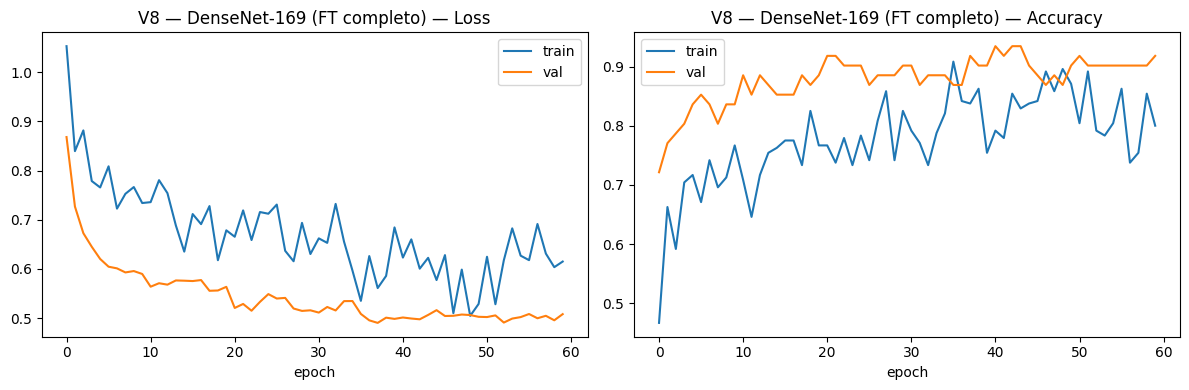

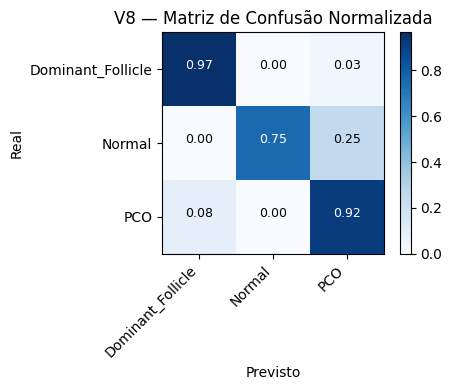

                   precision    recall  f1-score   support

Dominant_Follicle       0.93      0.97      0.95        29
           Normal       1.00      0.75      0.86         8
              PCO       0.88      0.92      0.90        24

         accuracy                           0.92        61
        macro avg       0.94      0.88      0.90        61
     weighted avg       0.92      0.92      0.92        61



In [32]:
plot_curves(history_v8, "V8 — DenseNet-169 (FT completo)")
plot_cm(yt_v8, yp_v8, CLASS_NAMES, "V8", normalize=True)
print(classification_report(yt_v8, yp_v8, target_names=CLASS_NAMES))


> **Observação V8:** *(preencher após execução)*

---
## Consolidação Final — Todos os Resultados


In [33]:
print("\n=== TABELA CONSOLIDADA ===")
print_results_table()



=== TABELA CONSOLIDADA ===
Var    Backbone                          Acc     F1   Prec    Rec   Loss  Tempo
───────────────────────────────────────────────────────────────────────────────
V1 DN-121 frozen DenseNet-121 (frozen)          0.8197 0.8289 0.8711 0.8084 0.5296   9.0m
V2 DN-169 frozen DenseNet-169 (frozen)          0.8525 0.8391 0.8526 0.8290 0.4462   7.8m
V3 DN-121 block4 DN-121 (block4)                0.8525 0.8536 0.8956 0.8338 0.3721   7.9m
V4 DN-121 +Scheduler DN-121 (block4+Sched)          0.8852 0.8659 0.9054 0.8453 0.3608   7.4m
V5 DN-121 blocks3+4 DN-121 (block3+4)              0.9344 0.9142 0.9500 0.8913 0.2169   8.5m
V6 DN-169 256px DN-169 (block3+4, 256)         0.9180 0.9025 0.9163 0.8913 0.1838  16.2m
V7 DN-121 FT+TTA DN-121 (FT completo, TTA)      0.9344 0.9150 0.9511 0.8913 0.5599   9.8m
V8 DN-169 FT+TTA DN-169 (FT completo, TTA)      0.9180 0.9014 0.9378 0.8774 0.5079  14.2m


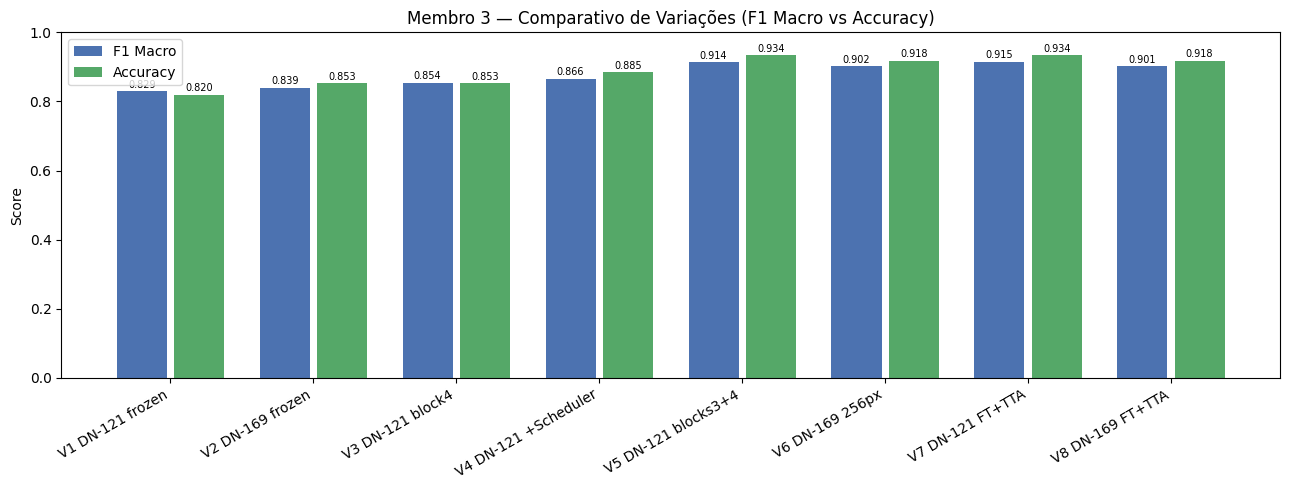

In [34]:
# Gráfico comparativo de F1 Macro entre variações
if ALL_RESULTS:
    nomes = [r["variacao"] for r in ALL_RESULTS]
    f1s   = [r["f1_macro"] for r in ALL_RESULTS]
    accs  = [r["accuracy"] for r in ALL_RESULTS]

    x = np.arange(len(nomes))
    fig, ax = plt.subplots(figsize=(13, 5))
    bars = ax.bar(x - 0.2, f1s,  0.35, label="F1 Macro", color="#4C72B0")
    bars2= ax.bar(x + 0.2, accs, 0.35, label="Accuracy",  color="#55A868")
    ax.set_xticks(x); ax.set_xticklabels(nomes, rotation=30, ha="right")
    ax.set_ylim(0, 1); ax.set_ylabel("Score"); ax.legend()
    ax.set_title("Membro 3 — Comparativo de Variações (F1 Macro vs Accuracy)")
    for b in list(bars) + list(bars2):
        ax.text(b.get_x()+b.get_width()/2, b.get_height()+0.01,
                f"{b.get_height():.3f}", ha="center", fontsize=7)
    plt.tight_layout(); plt.show()


---
## Notas para o Relatório

Copie esta tabela para o documento do grupo após preencher todas as variações:

| Var. | Backbone | Accuracy | F1 Macro | Precision | Recall | Tempo | Observações |
|---|---|---|---|---|---|---|---|
| V1 | DenseNet-121 frozen | | | | | | |
| V2 | DenseNet-169 frozen | | | | | | |
| V3 | DN-121 DenseBlock 4 livre | | | | | | |
| V4 | DN-121 DenseBlock 4 + Scheduler | | | | | | |
| V5 | DN-121 DenseBlocks 3+4 livres | | | | | | |
| V6 | DN-169 DenseBlocks 3+4 256px | | | | | | |
| V7 | DN-121 FT completo + TTA | | | | | | |
| V8 | DN-169 FT completo + TTA | | | | | | |
